In [ ]:
import pandas as pd
import tqdm
import torch

In [ ]:
from torch import nn
import torch.nn.functional as F

In [ ]:
relu = nn.ReLU()

In [ ]:
import torch
import torch.nn.functional as F
import random


class EnglishToGermanDataset(torch.utils.data.Dataset):
    def __init__(self):
        super().__init__()

        print("LOADING GERMAN SENTENCES")
        load = torch.load("/content/German_sentences.pkl")
        self.german_sentences_train = load["train_data"]
        self.german_sentences_test  = load["test_data"]
        self.german_vocab_len = load["vocab_len"]
        self.german_vocab = load["vocab"]
        self.german_vocab_reversed = load["vocab_reversed"]
        self.german_eos = self.german_vocab["<end>"]

        print("LOADING ENGLISH SENTENCES")
        load = torch.load("/content/English_sentences.pkl")
        self.english_sentences_train = load["train_data"]
        self.english_sentences_test  = load["test_data"]
        self.english_vocab = load["vocab"]
        self.english_vocab_len = load["vocab_len"]
        self.english_vocab_reversed = load["vocab_reversed"]
        self.english_eos = self.english_vocab["<end>"]

        self.min_len = 30
        self.mode = "train"

        # 🔥 filter out fully padded sentence pairs
        self.train_indices = self._build_valid_indices(
            self.german_sentences_train,
            self.english_sentences_train
        )
        self.test_indices = self._build_valid_indices(
            self.german_sentences_test,
            self.english_sentences_test
        )

        print(f"Train samples after filtering: {len(self.train_indices)}")
        print(f"Test  samples after filtering: {len(self.test_indices)}")

    # --------------------------------------------------
    # filtering logic
    # --------------------------------------------------
    def _build_valid_indices(self, german_sents, english_sents):
        valid = []
        for i, (g, e) in enumerate(zip(german_sents, english_sents)):
            # drop ONLY if both are fully <end>
            if not (
                torch.all(g == self.german_eos) and
                torch.all(e == self.english_eos)
            ):
                valid.append(i)
        return valid

    # --------------------------------------------------
    # mode control
    # --------------------------------------------------
    def train(self):
        self.mode = "train"

    def test(self):
        self.mode = "test"

    # --------------------------------------------------
    # length
    # --------------------------------------------------
    def __len__(self):
        return len(
            self.test_indices if self.mode == "test"
            else self.train_indices
        )

    # --------------------------------------------------
    # get item
    # --------------------------------------------------
    def __getitem__(self, idx):
        real_idx = (
            self.test_indices[idx]
            if self.mode == "test"
            else self.train_indices[idx]
        )

        german_item = (
            self.german_sentences_test[real_idx]
            if self.mode == "test"
            else self.german_sentences_train[real_idx]
        )
        english_item = (
            self.english_sentences_test[real_idx]
            if self.mode == "test"
            else self.english_sentences_train[real_idx]
        )

        min_len = min(len(german_item), len(english_item))

        start = torch.tensor([self.german_vocab["<start>"]], dtype=torch.long)
        end   = torch.tensor([self.german_vocab["<end>"]], dtype=torch.long)

        # -------- crop or pad --------
        if min_len > self.min_len:
            crop = random.randint(0, min_len - self.min_len)
            german_item  = german_item[crop : crop + self.min_len]
            english_item = english_item[crop : crop + self.min_len]

            logit_mask = torch.ones(self.min_len + 2, 1, dtype=torch.bool)
        else:
            german_item = F.pad(
                german_item,
                (0, self.min_len - len(german_item)),
                value=self.german_eos,
            )
            english_item = F.pad(
                english_item,
                (0, self.min_len - len(english_item)),
                value=self.english_eos,
            )

            logit_mask = torch.ones(self.min_len + 2, 1, dtype=torch.bool)
            logit_mask[min_len + 1 :] = 0

        german_item = torch.cat([start, german_item, end])

        # -------- one-hot targets (CPU) --------
        german_logits = torch.zeros(
            len(german_item),
            self.german_vocab_len,
            dtype=torch.float32,
        )
        german_logits[
            torch.arange(len(german_item)),
            german_item
        ] = 1.0

        return {
            "german": german_item,     # CPU
            "english": english_item,   # CPU
            "logits": german_logits,   # CPU
            "logit_mask": logit_mask,  # CPU
        }


In [ ]:
def scaled_dot_product(q, k, v, mask=False, dropout=None, pad_mask_in=None, pc="self_attn"):
    """
    Args:
        q: [batch, heads, seq_q, head_dim]
        k: [batch, heads, seq_k, head_dim]
        v: [batch, heads, seq_k, head_dim]
        mask: bool, if True apply causal masking (for decoder self-attention)
        pad_mask_in: [batch, seq] - True where padding is
        pc: "self_attn" or "cross_attn" (for debugging)
    """

    head_dim = q.shape[-1]

    # Compute attention scores
    scaled_attention = q @ k.transpose(-2, -1)  # [batch, heads, seq_q, seq_k]
    scaled_attention = scaled_attention / (head_dim ** 0.5)
    # Debug prints
    # if pc == "cross_attn" or False:  # Set to True for debugging
    #     print(f"\n[{pc}] Scaled attention shape: {scaled_attention.shape}")
    #     print(f"[{pc}] Q shape: {q.shape}, K shape: {k.shape}, V shape: {v.shape}")

    # Build mask
    final_mask = None

    # 1. Causal mask (for decoder self-attention)
    if mask:
        seq_q, seq_k = scaled_attention.shape[-2], scaled_attention.shape[-1]
        causal_mask = torch.triu(
            torch.ones(seq_q, seq_k, device=scaled_attention.device),
            diagonal=1
        ).bool()  # [seq_q, seq_k] - True where future is
        causal_mask = causal_mask[None, None, :, :]  # [1, 1, seq_q, seq_k]
        final_mask = causal_mask

        if pc == "cross_attn" or False:
            print(f"[{pc}] Causal mask shape: {causal_mask.shape}")

    # 2. Padding mask
    if pad_mask_in is not None:
        # pad_mask_in: [batch, seq_k] - True where padding is
        # We need: [batch, 1, 1, seq_k] to broadcast over heads and queries
        padding_mask = pad_mask_in[:, None, None, :]  # [batch, 1, 1, seq_k]

        if final_mask is None:
            final_mask = padding_mask
        else:
            # Combine causal and padding masks
            final_mask = final_mask | padding_mask


    # Apply mask
    if final_mask is not None:

        # Verify shapes match
        assert final_mask.shape[-1:] == scaled_attention.shape[-1:], \
            f"Mask shape {final_mask.shape} doesn't match attention {scaled_attention.shape}"

        scaled_attention = scaled_attention.masked_fill(final_mask, float("-inf"))

        # Check if any row is completely masked
        if torch.isinf(scaled_attention).all(dim=-1).any():
            print(f"WARNING [{pc}]: Some queries have all keys masked!")
            # Replace -inf rows with zeros before softmax to avoid NaN
            all_masked = torch.isinf(scaled_attention).all(dim=-1, keepdim=True)
            scaled_attention = torch.where(all_masked, torch.zeros_like(scaled_attention), scaled_attention)

    # Softmax
    scaled_attention = F.softmax(scaled_attention, dim=-1)

    # Verify attention weights sum to 1
    attn_sums = scaled_attention.sum(dim=-1)
    if not torch.allclose(attn_sums, torch.ones_like(attn_sums), atol=1e-5):
        print(f"WARNING [{pc}]: Attention weights don't sum to 1! Range: [{attn_sums.min():.4f}, {attn_sums.max():.4f}]")

    # if dropout is not None:
    #     scaled_attention = dropout(scaled_attention)

    output = scaled_attention @ v

    return output, scaled_attention

In [ ]:
class Embedding(nn.Module):
    def __init__(self, embed_dim, vocab, max_seq_len=512,cuda=True):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab, embedding_dim=embed_dim)
        self.position_embedding = nn.Embedding(num_embeddings=max_seq_len, embedding_dim=embed_dim)
        self.embed_dim = embed_dim

    def forward(self, x):
        batch_size, seq_len = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x = self.embedding(x) + self.position_embedding(positions)
        return x


In [ ]:
def prepare_qkv(input, batch_size, seq_len, num_heads, head_dim, projection):

  out = projection(input)

  out = out.reshape(batch_size, seq_len, num_heads, head_dim)
  out = out.permute(0,2,1,3)
  return out


In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, embed_dim,num_heads,cuda=False):
#     self.encoder = nn.LSTM(
#     input_size=embed_dim,
#     hidden_size=hidden_dim,
#     batch_first=True
# )
#     self.decoder = nn.LSTM(input_size = output_dim,
#                            hidden_size = hidden_dim,
#                            batch_first=True)
    # print("vocab", vocab)
    super().__init__()
    # assert embed_dim%num_heads==0

    self.q_projection = nn.Linear(embed_dim, embed_dim)
    self.k_projection = nn.Linear(embed_dim, embed_dim)
    self.v_projection = nn.Linear(embed_dim, embed_dim)
    self.out_projection = nn.Linear(embed_dim, embed_dim)
    self.norm = nn.LayerNorm(embed_dim)
    self.dropout = nn.Dropout(0.2)
    self.num_heads = num_heads
    self.head_dim = embed_dim//num_heads
    assert embed_dim%num_heads == 0
    # self.device = torch.device("cuda:0" if cuda else "cpu")


  def forward(self, q_in, k_in, v_in, residual_x, pad_mask, mask=False, pc="self_attn"):

    # 🔥 PRE-NORM (THIS IS THE FIX)
    q_norm = q_in
    k_norm = k_in
    v_norm = v_in
    batch_size, seq_len = q_norm.shape[0], q_norm.shape[1]
    k_batch_size, k_seq_len = k_norm.shape[0], k_norm.shape[1]

    Q = prepare_qkv(q_norm, batch_size, seq_len,
                    self.num_heads, self.head_dim, self.q_projection)

    K = prepare_qkv(k_norm, k_batch_size, k_seq_len,
                    self.num_heads, self.head_dim, self.k_projection)

    V = prepare_qkv(v_norm, k_batch_size, k_seq_len,
                    self.num_heads, self.head_dim, self.v_projection)

    attended_value, attention = scaled_dot_product(
        Q, K, V,
        mask=mask,
        dropout=self.dropout,
        pad_mask_in=pad_mask,
        pc=pc
    )

    attended_value = attended_value.permute(0,2,1,3)
    attended_value = attended_value.reshape(batch_size, seq_len, embed_dim)

    out = self.out_projection(attended_value)

    # residual WITHOUT norm now
    return out

    # self.attn_Q = nn.Lin

In [ ]:
class PositionalFeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim=None, dropout=0.1):
        super().__init__()

        if hidden_dim is None:
            hidden_dim = 4 * embed_dim   # standard transformer width

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.activation = nn.GELU()   # better than ReLU for transformers

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)

        return x


In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()

        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.ff = PositionalFeedForward(embed_dim, dropout=dropout)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask):

        # ---- Self Attention (Pre-Norm) ----
        res_x = x
        x = self.norm1(x)
        attn_out = self.attn(
            x, x, x,
            residual_x=res_x, # This parameter is unused in MultiHeadAttention, but kept for signature consistency
            pad_mask=pad_mask,
            mask=False
        )

        attn_out =  res_x+self.dropout(attn_out) # Corrected residual connection
        norm_attn_out = self.norm2(attn_out)
        # ---- Feed Forward ----
        ff_x = self.ff(norm_attn_out)
        x = attn_out+self.dropout(ff_x)
        return x

In [ ]:

class Encoder(nn.Module):
  def __init__(self, embed_dim, num_blocks,num_heads,cuda=False):
    super().__init__()
    self.blocks = nn.ModuleList([
            EncoderBlock(embed_dim,num_heads) for _ in range(num_blocks)
        ])
    self.device = torch.device("cuda:0" if CUDA else "cpu")
    # self.embedding = Embedding(embed_dim,vocab)
  def forward(self,x,pad_mask_in):
    # x = self.embedding(x)
    for block in self.blocks:
      x = block(x,pad_mask_in)
    # x = self.fc(x)
    return x

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, embed_dim,num_heads, cuda=False):
        super().__init__()
        # Every block now has its OWN private weights for BOTH types of attention
        self.self_attn = MultiHeadAttention(embed_dim,num_heads, cuda=cuda)
        self.cross_attn = MultiHeadAttention(embed_dim,num_heads, cuda=cuda)
        self.ff = PositionalFeedForward(embed_dim, embed_dim)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2= nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(0.1)
    def forward(self, x, encoder_outs, pad_mask_tgt, pad_mask_src, causal=False):
        # 1. Look at itself (German to German)
        res_x = x
        x = self.norm1(x)
        self_attn_out = self.self_attn(x, x, x, x, pad_mask=pad_mask_tgt, mask=causal)
        self_attn_out = self.dropout(self_attn_out)+res_x
        norm_self_attn_out = self.norm2(self_attn_out)
        # 2. Look at the encoder (German to English)
        # Note: Query is x, but Key/Value are from the encoder
        cross_attn_out = self.cross_attn(norm_self_attn_out, encoder_outs, encoder_outs, x, pad_mask=pad_mask_src, mask=False,pc="cross_attn")
        cross_attn_out = self.dropout(cross_attn_out)+self_attn_out
        # 3. Process with Feed Forward
        norm_cross_attn_out = self.norm3(cross_attn_out)
        ff_out = self.ff(norm_cross_attn_out)
        ff_out = self.dropout(ff_out)+cross_attn_out
        return ff_out

In [ ]:
class Decoder(nn.Module):
  def __init__(self, embed_dim, vocab, num_blocks,num_heads,cuda=False):
    super().__init__()
    self.blocks = nn.ModuleList([
            DecoderBlock(embed_dim,num_heads, cuda=cuda) for _ in range(num_blocks)
        ])
    self.fc = nn.Linear(embed_dim, vocab) # we can also say this converting back to logits??
    self.device = torch.device("cuda:0" if CUDA else "cpu")
  def forward(self,x, encoder_outs,mask=False,pad_mask=None,pad_mask_in=None):
    for block in self.blocks:
      x = block(x,encoder_outs,pad_mask,pad_mask_in,mask) # we have to include last dim alone in query?? to support auto regressive generation but not in training , we have to use mask
      # x = block(attention_outs, encoder_outs, encoder_outs, attention_outs,pad_mask_in=pad_mask_in)
    x = self.fc(x)
    return x


In [ ]:
class TransformerTranslator(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_blocks,
        num_heads,
        encoder_vocab_size,
        output_vocab_size,
        CUDA=False,
    ):
        super().__init__()

        self.encoder_embedding = Embedding(embed_dim,encoder_vocab_size,cuda=CUDA)
        self.output_embedding = Embedding(embed_dim, output_vocab_size,cuda=CUDA)

        self.encoder = Encoder(embed_dim, num_blocks,num_heads, cuda=CUDA)
        self.decoder = Decoder(
            embed_dim, output_vocab_size,num_blocks,num_heads, cuda=CUDA
        )

        self.encoded = False
        self.output_embedding.weight = self.decoder.fc.weight # Corrected: 'weights' to 'weight'
        self.device = torch.device("cuda:0" if CUDA else "cpu")

    def encode(self, input_sequence):
      PAD_ID = 1
      pad_mask_in = (input_sequence == PAD_ID)
      ip_embedding = self.encoder_embedding(input_sequence)
      self.encode_out = self.encoder(ip_embedding, pad_mask_in)

    def forward(self, input_sequence, output_sequence,mask=False):
        PAD_ID = 1
        pad_mask_out = (output_sequence == PAD_ID)
        pad_mask_in = (input_sequence == PAD_ID)
        print("pad_mask_in_shape",pad_mask_in.shape)
        op_embedding = self.output_embedding(output_sequence)
        return self.decoder(op_embedding, self.encode_out,mask=mask,pad_mask=pad_mask_out,pad_mask_in = pad_mask_in)

In [ ]:
from torch.utils.data import DataLoader
device = "cuda:0"
CUDA = True
dataset = EnglishToGermanDataset()
dataset.train()   # or dataset.test()
batch_size =32
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

LOADING GERMAN SENTENCES
LOADING ENGLISH SENTENCES
Train samples after filtering: 799
Test  samples after filtering: 801


In [ ]:

dataset.test()   # or dataset.test()

test_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

In [ ]:
# dataset.to("cuda:0")

In [ ]:

alpha = 3e-4
num_heads = 8           # Standard
num_blocks = 6          # Standard (like original Transformer)
hidden_dim = 256       # More capacity
embed_dim = hidden_dim  # 256
head_dim = embed_dim // num_heads  # 32
num_epochs = 15
encoder_vocab_size = dataset.english_vocab_len
output_vocab_size = dataset.german_vocab_len

In [ ]:
PAD_ID = 1

In [ ]:
# print("outpt", output_vocab_size)
model =TransformerTranslator(embed_dim,num_blocks,num_heads,encoder_vocab_size, output_vocab_size,CUDA=CUDA)
model=model.to(device)
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=alpha)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID,label_smoothing=0.1)
def train(batch):
    optimizer.zero_grad()
    #  # y: (T,)
    # print(batch["german"])
    decoder_in = batch["german"][:, :-1]
    target     = batch["german"][:, 1:]
    model.encode(batch["english"])
    output = model(batch["english"], decoder_in, mask=True)
    output = output.reshape(-1, output_vocab_size)

    y = target.reshape(-1)

    loss = criterion(output, y)

    loss.backward()
    optimizer.step()

    return loss.item(), output

In [ ]:
SAVE_INTERVAL = 5000

In [ ]:
import math
import os
from tqdm import tqdm
import random

In [ ]:
losses = []
val_losses = []

num = 0
bat = None

model.train()

for epoch in tqdm(range(num_epochs)):
    running_train_loss = []
    running_validation_loss = []

    # ---------- TRAIN ----------
    for batch in loader:
        # 🔑 move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}

        # print(batch["logit_mask"].device)  # should be cuda

        bat = batch
        loss, output = train(batch)

        assert math.isfinite(loss), f"Loss is nan : {loss}"

        running_train_loss.append(loss)
        num += 1
    #     break
    # break

    # ---------- VALIDATION ----------
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            model.encode(batch["english"])

            decoder_in = batch["german"][:, :-1]
            target     = batch["german"][:, 1:]

            output = model(
                batch["english"],
                decoder_in,
                mask=True
            )

            output = output.reshape(-1, output_vocab_size)
            y = target.reshape(-1)

            loss = criterion(output, y)
            running_validation_loss.append(loss.item())

    avg_train_loss = sum(running_train_loss) / len(running_train_loss)
    avg_test_loss  = sum(running_validation_loss) / len(running_validation_loss)

    losses.append(avg_train_loss)
    val_losses.append(avg_test_loss)

    # ---------- CHECKPOINT ----------
    if num % SAVE_INTERVAL == 0:
        os.makedirs("/content/Checkpoints", exist_ok=True)
        save_path = os.path.join(
            "/content/Checkpoints",
            f"Checkpoint{num}.pkl"
        )
        torch.save(
            {
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "num_steps": num,
                "train_losses": losses,
                "test_losses": val_losses,
            },
            save_path,
        )

    model.train()


  0%|          | 0/15 [00:00<?, ?it/s]

pad_mask_in_shape torch.Size([32, 30])
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_i

  7%|▋         | 1/15 [00:03<00:45,  3.27s/it]

pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
WARNING [self_attn]: Some queries have all keys m

 13%|█▎        | 2/15 [00:06<00:40,  3.08s/it]

...

pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_i

 93%|█████████▎| 14/15 [00:41<00:02,  2.89s/it]

pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])
pad_mask_i

100%|██████████| 15/15 [00:44<00:00,  2.99s/it]

WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
WARNING [self_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
WARNING [cross_attn]: Some queries have all keys masked!
pad_mask_in_shape torch.Size([32, 30])
pad_mask_in_shape torch.Size([32, 30])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:


def plot_50_day_moving_losses(losses, window=50):
  mod =losses
  if not isinstance(losses[0], float):
    mod = [loss.to("cpu") for loss in losses]
  # losses = losses.to("cpu")
  losses_np = np.array(mod)

  moving_avg = np.convolve(
      losses_np,
      np.ones(window) / window,
      mode="valid"
  )

  plt.plot(moving_avg)
  plt.title(f"{window}  Moving Average Loss")
  plt.xlabel("Time")
  plt.ylabel("Loss")


In [ ]:
def translate_sentence(model, sentence, tokenizer, max_len=20, device="cuda"):
    model.eval()

    src_ids = tokenizer.encode(sentence).ids
    src = torch.tensor(src_ids, device=device).unsqueeze(0)

    # Encode once
    model.encode(src)

    bos_id = tokenizer.token_to_id("<bos>")
    eos_id = tokenizer.token_to_id("<eos>")

    tgt = torch.tensor([[bos_id]], device=device)

    with torch.no_grad():
        for i in range(max_len):

            logits = model(src, tgt, mask=True)

            # Greedy: pick highest probability token
            next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)

            tgt = torch.cat([tgt, next_token], dim=1)

            if next_token.item() == eos_id:
                break

    return tokenizer.decode(tgt.squeeze(0).tolist())


In [ ]:
def translate_sentence_ablate(model, sentence, tokenizer, max_len=20, device="cuda"):
    model.eval()

    src_ids = tokenizer.encode(sentence).ids
    src = torch.tensor(src_ids, device=device).unsqueeze(0)

    # Encode once
    model.encode(src)
    # 🔴 ABLATION: destroy encoder information
    encoder_outs = torch.zeros_like(model.encode_out)
    model.encode_out = encoder_outs
    bos_id = tokenizer.token_to_id("<bos>")
    eos_id = tokenizer.token_to_id("<eos>")

    tgt = torch.tensor([[bos_id]], device=device)

    with torch.no_grad():
        for _ in range(max_len):

            # IMPORTANT: pass encoder_outs explicitly
            logits = model(src, tgt, mask=True)
            next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
            tgt = torch.cat([tgt, next_token], dim=1)

            if next_token.item() == eos_id:
                break
    # print("tokenizer", tokenizer)
    return tokenizer.decode(tgt.squeeze(0).tolist())


In [ ]:
test_df["translation"][10]

NameError: name 'test_df' is not defined

In [ ]:
s = "I bought some groceries yesterday"

In [ ]:
translate_sentence(model, s, tokenizer)

'An dieser Stelle iert – Erstens ze k ze N uklear ad k ze verfügbar habe Ich habe meiner Nachrichten'

In [ ]:

translate_sentence_ablate(
    model, s, tokenizer=tokenizer )

'Es gibt keine Leben re ste , die kürzlich , die Mehrheit te ganz block so viel über listen ung'

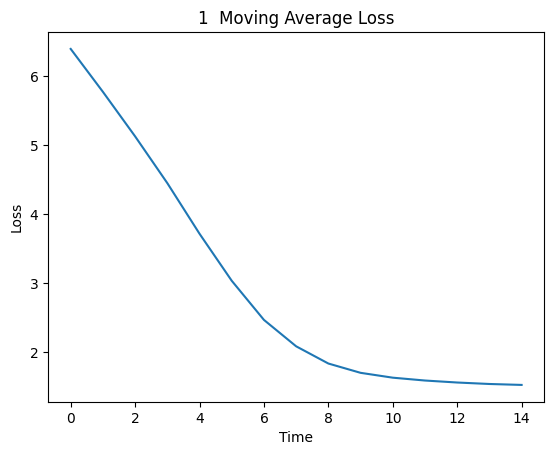

In [ ]:
plot_50_day_moving_losses(val_losses,1)


In [ ]:
mat = mat[0]
mat1= mat[0]
mat2=mat[1]
mat3 = mat[2]

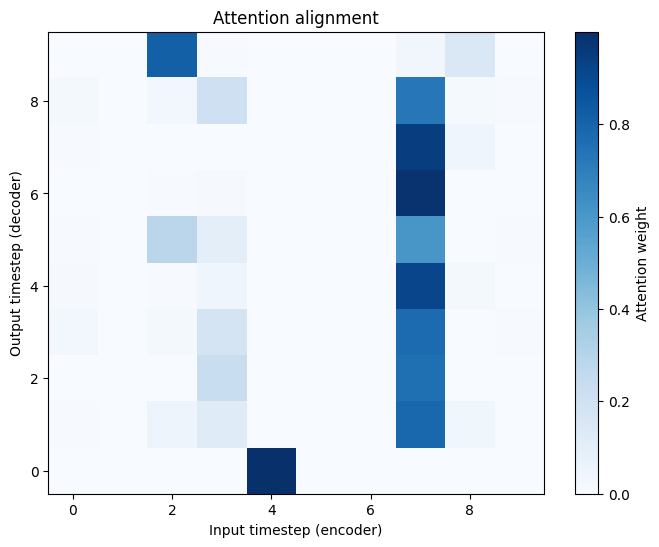

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

attn = mat3.detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.imshow(attn, aspect="auto", origin="lower", cmap="Blues")
plt.colorbar(label="Attention weight")

plt.xlabel("Input timestep (encoder)")
plt.ylabel("Output timestep (decoder)")
plt.title("Attention alignment")

plt.show()



In [ ]:
def test_attention_mechanism():
    """Test attention with known inputs"""

    batch_size = 2
    num_heads = 4
    seq_len_q = 5  # decoder sequence length
    seq_len_kv = 7  # encoder sequence length
    head_dim = 16

    # Create random Q, K, V
    q = torch.randn(batch_size, num_heads, seq_len_q, head_dim)
    k = torch.randn(batch_size, num_heads, seq_len_kv, head_dim)
    v = torch.randn(batch_size, num_heads, seq_len_kv, head_dim)

    print("=" * 50)
    print("TEST 1: Self-Attention (no masking)")
    print("=" * 50)
    k_self = q.clone()
    v_self = q.clone()
    out, attn = scaled_dot_product(q, k_self, v_self, None, mask=False, pad_mask_in=None)
    print(f"Output shape: {out.shape}")
    print(f"Attention shape: {attn.shape}")
    print(f"Attention sums (should be ~1.0): {attn.sum(dim=-1)}")
    assert torch.allclose(attn.sum(dim=-1), torch.ones_like(attn.sum(dim=-1))), "Attention weights don't sum to 1!"

    print("\n" + "=" * 50)
    print("TEST 2: Self-Attention with Causal Mask")
    print("=" * 50)
    pad_mask_in = torch.zeros(batch_size, seq_len_q, dtype=torch.bool)
    out, attn = scaled_dot_product(q, k_self, v_self, None, mask=True, pad_mask_in=pad_mask_in)
    print(f"Attention weights:\n{attn[0, 0]}")  # First head of first batch
    # Check causal: position i should only attend to positions <= i
    for i in range(seq_len_q):
        future_attn = attn[0, 0, i, i+1:]  # Attention to future positions
        assert torch.allclose(future_attn, torch.zeros_like(future_attn)), f"Position {i} attending to future!"
    print("✓ Causal masking correct")

    print("\n" + "=" * 50)
    print("TEST 3: Cross-Attention with Padding Mask")
    print("=" * 50)
    # Simulate padding: last 2 positions are padding
    pad_mask_in = torch.zeros(batch_size, seq_len_kv, dtype=torch.bool)
    pad_mask_in[:, -2:] = True  # Mark last 2 as padding

    out, attn = scaled_dot_product(q, k, v, None, mask=False, pad_mask_in=pad_mask_in)
    print(f"Attention to padded positions (should be ~0):\n{attn[0, 0, :, -2:]}")

    # Check padding is masked
    assert torch.allclose(attn[:, :, :, -2:], torch.zeros_like(attn[:, :, :, -2:])), "Padding not masked!"
    print("✓ Padding masking correct")

    print("\n" + "=" * 50)
    print("TEST 4: Decoder Self-Attention (Causal + Padding)")
    print("=" * 50)
    # Some positions are padding
    pad_mask_in = torch.zeros(batch_size, seq_len_q, dtype=torch.bool)
    pad_mask_in[0, -1] = True  # Last position of first batch is padding

    out, attn = scaled_dot_product(q, k_self, v_self, None, mask=True, pad_mask_in=pad_mask_in)
    print(f"Attention matrix (batch 0, head 0):\n{attn[0, 0]}")

    # Check combined masking
    print(f"Attention to padding (should be 0): {attn[0, 0, :, -1]}")
    print("✓ Combined masking correct")

    print("\n" + "=" * 50)
    print("ALL TESTS PASSED! ✓")
    print("=" * 50)

# Run tests
test_attention_mechanism()

TEST 1: Self-Attention (no masking)
Output shape: torch.Size([2, 4, 5, 16])
Attention shape: torch.Size([2, 4, 5, 5])
Attention sums (should be ~1.0): tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]]])

TEST 2: Self-Attention with Causal Mask
Attention weights:
tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [2.4372e-04, 9.9976e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [3.9381e-03, 4.6188e-02, 9.4987e-01, 0.0000e+00, 0.0000e+00],
        [4.6167e-02, 7.6429e-02, 3.3398e-02, 8.4401e-01, 0.0000e+00],
        [4.0171e-04, 2.6507e-02, 3.9721e-03, 1.1624e-02, 9.5750e-01]])
✓ Causal masking correct

